    **The theories are referenced from the lecture note of Complex Physics course by Kim Sneppen(of KU)**

# The Stock market
    The stock market refers to the collection of markets and exchanges where regular activities of buying, 
    selling, and issuance of shares of publicly-held companies take place. (Investopedia)

If one could predict the stock market, one would surely make a profit .. unfortunately that is an ancient dream as such market is almost unpredictable!

### The stock market approximately exhibits a biased random walk in $log(price)$

we define this log quantity as, $s$:

         s(t) = log(v(t)) 

where the price, $v$, is of course a function that changes in time, $t$
    
    Here we are interested in the log of change because changes can be in any scale

In theory, a random walk has a dependent variable that is proportional to an independent variable to the power of $0.5$ :

        W (T ) ∝ T^{0.5}
  
In this case $T$ is a time interval


In [ ]:
import numpy as np
from scipy import interpolate
from scipy import integrate
from tqdm import tqdm
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

To simulate a stock market as a **'biased'** random walk, 
We take additional probability, $p$, as the **probability of the price continuing in the same direction as the previous step**

( so a biased random walk is a random walk that is trending in a direction i.e. increasing)

    Here I'm using an arbitrary probability p=0.75 that the price will persist in the same direction.
    (this can be change, up to p=0.99!)

In [185]:

def Stock(nmax,P,iniprice):
    v = []
    for i in range (nmax):            #  time steps
        
        newprice = iniprice + np.sign(iniprice) * np.random.choice((-1,1),1,p=[1-P,P] )          
                                      # x 1 = same direction 
                                      # x -1 = opposite direction
        iniprice = newprice
        v.append(iniprice)        
    return v

V = Stock(100,0.75,500)
t = np.linspace(0,100,len(V))

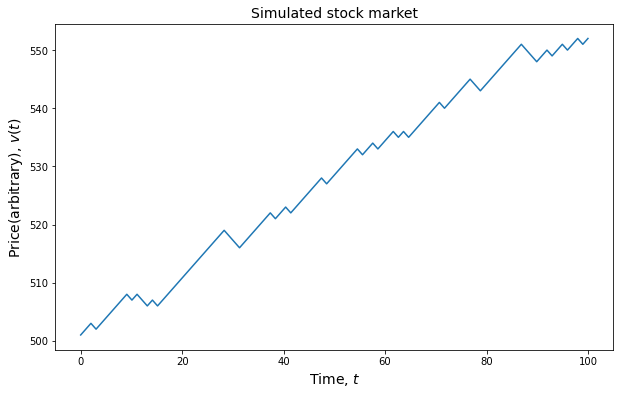

In [186]:
plt.figure(figsize=(10,6))
plt.title('Simulated stock market',fontsize='14')
plt.xlabel(r'Time, $t$',fontsize='14')
plt.ylabel(r'Price(arbitrary), $v(t)$',fontsize='14')
plt.plot( t,V)
plt.show()

## Hurst exponent
Is is true that it's nearly impossible to predict the stock market, but one can at least try .. to define correlation between the past and future.

Let's express the price difference between present time, $x$, and the **future** at a time, $T$, So we have : 
        ∆s(T) = s(T + $x$) − s($x$)

And price varation time $-T$ into the **past** : 
        ∆s(−T ) = s(x − T ) − s(x)

The **correlation** is then :
\begin{equation}
C ≡ \frac{⟨(s(t) − s(t − T)) · (s(t + T) − s(t))⟩_t  }{ ⟨(∆s(T))^2 ⟩_t}
\end{equation}

Here we can express the denominator as **'variance over time interval T'** :
\begin{equation}
f(T) = ⟨(∆s(T))^2 ⟩_t
\end{equation}

And the numerator as
\begin{equation}
⟨−∆s(−T )∆s(T )⟩t = \frac{1}{2} f(2T)−f(T)
\end{equation}

Using some maths trick that I will not write fully here.

We can also rewrite $f(T)$ by assuming that average of samples are taken over a long enough time ..
\begin{equation}
f(T) \propto T^{2H}
\end{equation}

Therefore,
\begin{equation}
C = \frac{⟨−∆s(−T) · ∆s(T)⟩_t}{⟨(∆s(T))^2 ⟩_t} =  2^{2H−1} − 1
\end{equation}

### **Interpretation:**

In an ordinary random walk, there is no correlation between future and the past; $C=0$ and so H = 1/2

$\bullet$ Where $H> 1/2 $, the price progression should be in the same direction. I.e. if the price increased during the past month, then it will, also on average increase during the next month.

    one can buy on the way up and sell on the way down

$\bullet$ In contrast, if $H< 1/2$ market the price fluctuations will tend to revert.
    
    So the strategy must be the opposite of the above


In real life, Hurst exponent of the stock market can range from $H \approx 0.55-0.65$, while energy market is $H \approx 0.4$.
Note that as long as the 'random walk' is characterised by $H$, one could use this interpretaion to devise a buy-sell strategy to gain profit

    Now we will calculate the Hurst exponent, H, from the stock market simulation from previously, by averaging the variance over larger and larger time steps. 
    I.e. : one hundred simulated time-series of length 100, hundred time-series of length 1,000, and hundred timeseries of length 10,000.

In [206]:
def Hurst(nmax,P):
    s = []
    for j in tqdm(range(100)):              # average over 100 simulations
       
        price = Stock(nmax,P,10)           # simulate stock over time=[100,1000,10000]
        price = np.array(price) 
        s.append( np.square(price) )  
                 
    return np.mean(s)
                 
                 
Hurst = np.vectorize(Hurst)

In [207]:
T = np.array([100,1000,10000])       # time steps
Hurst(T,0.75)

100%|█████████████████████████████████████████| 100/100 [00:54<00:00,  1.85it/s]


array([1.44644000e+03, 8.82605185e+04, 8.42084312e+06])

/var/folders/jh/x3tpwn315l39v9yh7tdfpfk80000gn/T/ipykernel_34163/1749049841.py:4: RuntimeWarning: overflow encountered in power
  return x**m


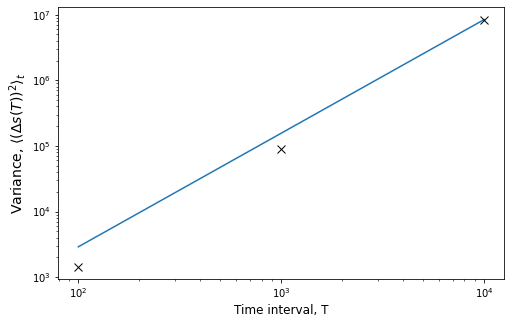

Hurst exponent ≈ [0.86566334] ± [0.0006206]


In [208]:
W2mean = np.array([  1.44644000e+03, 8.82605185e+04, 8.42084312e+06])

def func(x,m):
    return x**m   
popt, pcov  = curve_fit(func,T,W2mean )

plt.figure(figsize=(8,5))
plt.loglog()

plt.xlabel('Time interval, T',fontsize='12')
plt.ylabel('Variance, '+r'$⟨(∆s(T))^2 ⟩_t$',fontsize='14')
plt.plot( T ,func(T,*popt) )
plt.plot(T,W2mean,'x',color='black',markersize='8')
plt.show()

print('Hurst exponent ≈',popt/2, '±',np.sqrt(np.diag(pcov)) ) #error to one sigma

$\therefore$ The gradient on the log scale plot between Variance VS time interval **gives $2\times$ Hurst exponent**

The investment tactic mentioned above is valid as long as the market trend can be described by Hurst exponent

### An expression relating probabilty of following the trend to the Hurst exponent:
\begin{equation}
P \approx 4^{H-1}
\end{equation}

This is an approximatiton obtained by taking the variance per step of the simulation is 1 

(then substitute this into the expression for $C$ above- the algebra should check out)


In [259]:
print('Do we recove the probability p from H calculated above?')
print('From the approx formula above.. p ~ ', 4**(0.86566334-1) )

# p is actually 0.75 ...close enough?

Do we recove the probability p from H calculated above?:
From the approx formula above.. p ~  0.830082525974166


## Profit calculation

We will now test how well the investment strategy above work. 
Using the same simulation, if one ,for example, create a market with Hurst exponent $H>1/2$

This means the strategy is to **buy** on the way up i.e. when price at time $t-T$ is less than at $t$(present time).

Then we bet that the trend will keep up for time $t+T$(in the future) when we sell the stock!


In [218]:
def Profit(T,H):        # T = Investment horizon, H = Hurst exp
    
    P = 4**(H-1)        # approximating P from H
    s_past = 100        # arbitrary past price
    price = 99          # arbitrary present price(to start the while loop)
    
    while s_past > price :             
            
        price = Stock(T,P,s_past)[-1]       # let the stock run for time T
            
    # when present price > past price, we commit on buying the stock
    future = Stock(T,P,price)[-1]
            
    profit = (future-price)/price
    
    return profit

    How does the profit look after repeating this a few rounds?

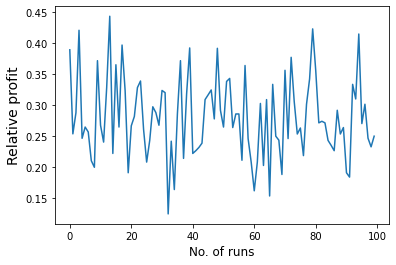

In [258]:
y = []

for i in range(100):
    y.append( Profit(100,0.75) ) #probablity p=0.75
    

plt.xlabel('No. of runs',fontsize='12')
plt.ylabel('Relative profit',fontsize='14')
plt.plot( y )

plt.show()

The better will always get the profit back in the case that the probability $p$ that the price will change in the same direction as the previous time step is 0.75

So if we change $p$, we will get less and less in return and of course will start losing if we dont change the strategy!(try it)

### What happen to the profit as we vary H exponent (and p) of the market?

In [245]:
Harray = np.linspace(0,1,10)

def profit_vsH(H):
    pro=[]
    for i in tqdm(range(3)): #average 10 times
        
        pro.append( Profit(T=50,H=H) )
        
    return np.mean(pro)

        
profit_vsH = np.vectorize(profit_vsH)

profit_vsH(Harray)

100%|█████████████████████████████████████████████| 3/3 [00:00<00:00, 63.83it/s]


array([-0.3       , -0.21058824, -0.20490028, -0.11011061, -0.02044579,
        0.06746427,  0.13573405,  0.13109255,  0.28753083,  0.33333333])

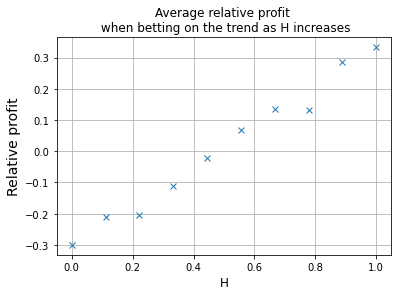

In [257]:
profit = np.array([-0.3       , -0.21058824, -0.20490028, -0.11011061, -0.02044579,
        0.06746427,  0.13573405,  0.13109255,  0.28753083,  0.33333333])

plt.title('Average relative profit \n when betting on the trend as H increases')

plt.xlabel('H',fontsize='12')
plt.ylabel('Relative profit',fontsize='14')
plt.plot( Harray ,profit,'x' )
plt.grid()

plt.show()

**It works.**

We can see that, clearly, the profit becomes positive at $H \geq= 0.5$ which indeed agreed with our strategy

As a final note.. stock markets in real life are affected by even more human factors such as fear factor.

To be continued.